In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import warnings
warnings.filterwarnings('ignore')

In [353]:
bmx_j = pd.read_sas('BMX_J.xpt', format='xport')
demo_j = pd.read_sas('DEMO_J.xpt', format='xport')
diq_j = pd.read_sas('DIQ_J.xpt', format='xport')

In [354]:
df = demo_j.merge(bmx_j, on='SEQN').merge(diq_j, on='SEQN')

print(df.shape) 

(8366, 119)


In [355]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Columns: 119 entries, SEQN to DIQ080
dtypes: float64(119)
memory usage: 7.6 MB


SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIAGENDR       0
RIDAGEYR       0
            ... 
DID341      7523
DID350      7523
DIQ350U     7686
DIQ360      7521
DIQ080      7521
Length: 119, dtype: int64

In [356]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SEQN,8366.0,98320.87,2669.90,93703.0,96003.25,98332.5,100629.75,102956.0
SDDSRVYR,8366.0,10.00,0.00,10.0,10.00,10.0,10.00,10.0
RIDSTATR,8366.0,2.00,0.00,2.0,2.00,2.0,2.00,2.0
RIAGENDR,8366.0,1.51,0.50,1.0,1.00,2.0,2.00,2.0
RIDAGEYR,8366.0,35.83,24.91,1.0,12.00,33.0,59.00,80.0
...,...,...,...,...,...,...,...,...
DID341,843.0,73.66,840.87,0.0,0.00,2.0,3.00,9999.0
DID350,843.0,25.05,486.68,0.0,1.00,1.0,1.00,9999.0
DIQ350U,680.0,1.56,0.82,1.0,1.00,1.0,2.00,4.0
DIQ360,845.0,2.58,1.27,1.0,2.00,2.0,3.00,9.0


In [357]:
Columns_to_keep = ['DIQ010', 'RIAGENDR', 'RIDAGEYR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST','RIDRETH1']
df = df[Columns_to_keep]

In [358]:
df = df.drop(columns=[col for col in df.columns if col not in Columns_to_keep])

Following the merge of the three datasets, the combined dataset initially contained 118 features. Feature selection was performed to remove irrelevant or redundant variables, resulting in a final set of 8 columns.

In [359]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
DIQ010,8366.0,1.92,0.37,1.0,2.0,2.0,2.0,9.0
RIAGENDR,8366.0,1.51,0.50,1.0,1.0,2.0,2.0,2.0
RIDAGEYR,8366.0,35.83,24.91,1.0,12.0,33.0,59.0,80.0
BMXWT,8242.0,67.50,31.38,8.3,48.7,69.2,86.5,242.6
BMXHT,8016.0,156.59,22.26,78.3,151.4,161.9,171.2,197.7
BMXBMI,8005.0,26.58,8.26,12.3,20.4,25.8,31.3,86.2
BMXWAIST,7601.0,89.93,22.81,40.0,73.9,91.2,105.3,169.5
RIDRETH1,8366.0,3.25,1.28,1.0,3.0,3.0,4.0,5.0


In [360]:
df = df.rename(columns={
    'DIQ010': 'Diabetes_status',
    'RIAGENDR': 'Gender',
    'RIDAGEYR': 'Age',
    'BMXWT': 'Weight',
    'BMXHT': 'Height',
    'BMXBMI': 'Bmi',
    'BMXWAIST': 'Waist',
    'RIDRETH1': 'Ethnicity'
})

In [361]:
df['Diabetes_status'] = df['Diabetes_status'].map({
    1.0: 'Diabetic',
    2.0: 'No Risk',
    3.0: 'Borderline'
})
df['Gender'] = df['Gender'].map({1.0: 'Male', 2.0: 'Female'})
df['Ethnicity'] = df['Ethnicity'].map({
    1.0: 'Mexican American',
    2.0: 'Other Hispanic', 
    3.0: 'Non-Hispanic White', 
    4.0: 'Non-Hispanic Black', 
    5.0: 'Other' })

To enhance interpretability and streamline exploratory data analysis (EDA), column names were standardized and renamed to more descriptive labels.

In [362]:
df = df[df['Diabetes_status'] != 9.0]

In [363]:
print(df.isnull().sum())

Diabetes_status      4
Gender               0
Age                  0
Weight             124
Height             350
Bmi                361
Waist              765
Ethnicity            0
dtype: int64


Missing values in the target variable were dropped due to their low frequency. For continuous features (height, weight, BMI, and waist circumference), median imputation was used to preserve the dataset while mitigating the influence of skewness and outliers.

In [364]:
df = df.dropna(subset=['Diabetes_status'])

df['Weight'] = df['Weight'].fillna(df['Weight'].median())
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Bmi'] = df['Bmi'].fillna(df['Bmi'].median())
df['Waist'] = df['Waist'].fillna(df['Waist'].median())

In [365]:
print(df.describe())
print(df['Diabetes_status'].value_counts())

               Age       Weight       Height          Bmi        Waist
count  8362.000000  8362.000000  8362.000000  8362.000000  8362.000000
mean     35.824922    67.521454   156.814733    26.542705    90.046640
std      24.904611    31.149856    21.817331     8.083542    21.744064
min       1.000000     8.300000    78.300000    12.300000    40.000000
25%      12.000000    49.200000   152.100000    20.700000    75.825000
50%      33.000000    69.200000   161.900000    25.800000    91.250000
75%      59.000000    86.200000   170.800000    31.000000   103.700000
max      80.000000   242.600000   197.700000    86.200000   169.500000
Diabetes_status
No Risk       7334
Diabetic       853
Borderline     175
Name: count, dtype: int64


During exploratory data analysis, the BMI variable exhibited extreme outliers, with maximum values far exceeding realistic human ranges. 
Given that BMI values above ~80 are highly unlikely, these observations were considered data entry errors or anomalies. 
To ensure data quality and improve model reliability, rows containing these extreme values were removed from the dataset.

In [366]:
df = df[df['Age'] >= 18]
df.shape

(5529, 8)

In [367]:
for col in ['Weight','Bmi','Waist']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[df[col] >= lower_bound]
    df = df[df[col] <= upper_bound]

In [368]:
df.describe()

,Age,Weight,Height,Bmi,Waist
count,5277.000000,5277.000000,5277.000000,5277.000000,5277.000000
mean,49.938980,79.471309,166.153970,28.686432,97.954245
std,18.765594,18.729848,9.909467,5.918010,14.821140
min,18.000000,32.600000,138.300000,14.200000,62.300000
25%,33.000000,66.000000,158.900000,24.500000,88.100000
50%,52.000000,77.200000,165.500000,28.000000,96.800000
75%,65.000000,91.500000,173.400000,32.500000,108.000000
max,80.000000,135.400000,197.700000,45.500000,138.300000


In [369]:
print(df['Diabetes_status'].value_counts())

Diabetes_status
No Risk       4356
Diabetic       770
Borderline     151
Name: count, dtype: int64


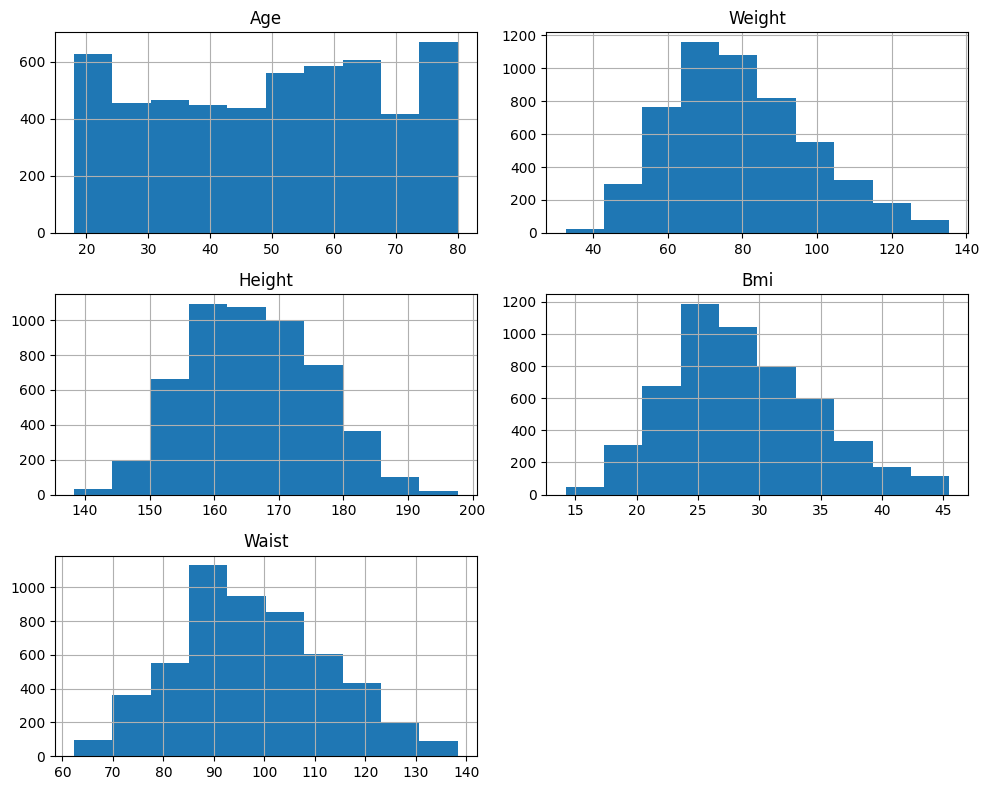

In [370]:
df.hist(figsize= (10,8))
plt.tight_layout()
plt.show()


In [371]:
print(df.skew(numeric_only=True))

Age      -0.068276
Weight    0.481441
Height    0.146050
Bmi       0.449254
Waist     0.211348
dtype: float64


In [372]:
df['Bmi_Age'] = df['Bmi'] * df['Age']
df['Waist_height'] = df['Waist'] / df['Height']

print(df[['Bmi_Age', 'Waist_height']].describe())

           Bmi_Age  Waist_height
count  5277.000000   5277.000000
mean   1439.085257      0.590684
std     617.058352      0.089855
min     280.800000      0.366152
25%     938.000000      0.529584
50%    1434.000000      0.585311
75%    1891.200000      0.650660
max    3616.000000      0.895585


In [373]:
print(df[['Bmi_Age', 'Waist_height']].skew())

Bmi_Age         0.215091
Waist_height    0.190662
dtype: float64


In [374]:
print(df.groupby('Diabetes_status')[['Bmi_Age', 'Waist_height']].mean())

                     Bmi_Age  Waist_height
Diabetes_status                           
Borderline       1734.515894      0.615622
Diabetic         1947.693636      0.638384
No Risk          1338.938682      0.581387


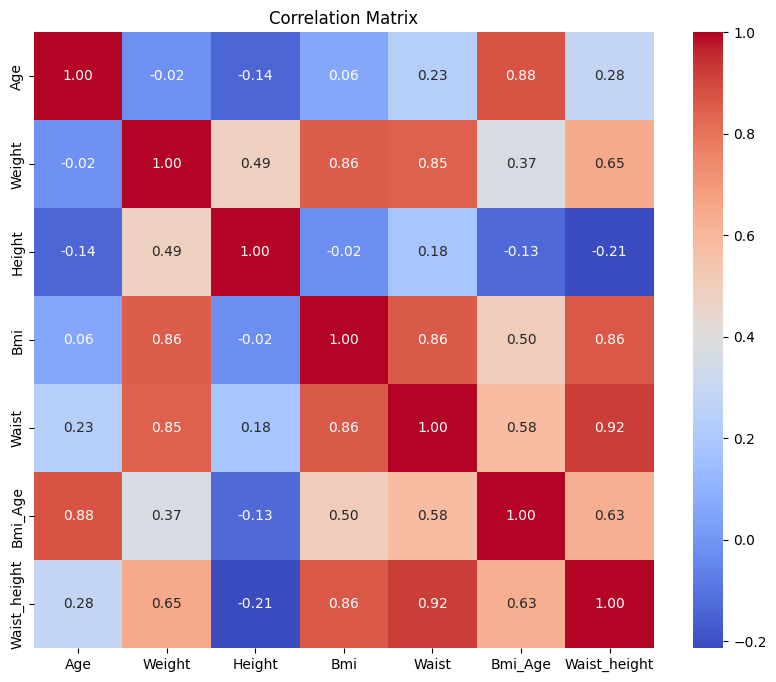

In [375]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

The heatmap indicates that waist circumference, weight, and BMI are highly correlated, suggesting these features capture similar information about body composition.

In [376]:
df = df.drop(['Weight', 'Waist'], axis=1)
print(df.columns.tolist())

['Diabetes_status', 'Gender', 'Age', 'Height', 'Bmi', 'Ethnicity', 'Bmi_Age', 'Waist_height']


In [377]:
X = df.drop('Diabetes_status', axis=1)
y = df['Diabetes_status']

In [378]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [379]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())

(4221, 7)
(1056, 7)
Diabetes_status
No Risk       3484
Diabetic       616
Borderline     121
Name: count, dtype: int64


After completing my exploratory data analysis (EDA), I began the preprocessing stage.

In [380]:
num_cols = ['Age', 'Height','Bmi', 'Bmi_Age', 'Waist_height']
cat_cols = ['Gender', 'Ethnicity']

In [381]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [382]:
pipeline = {
    'Logistic Regression': ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    'Random Forest': ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': ImbPipeline(steps=[
        ('preprocessor', preprocessor),
            ('smote', SMOTE(
            sampling_strategy={
                'Borderline': 200,
                'Diabetic': 1500
            },
            random_state=42
        )),
        ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
}

In [383]:
best_model = None
best_acc = 0
best_name = ""

le = LabelEncoder()

# Encode the target variables
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

for name, pipe in pipeline.items():
    if name == 'XGBoost':
        pipe.named_steps['smote'].sampling_strategy = {
            le.transform(['Borderline'])[0]: 200,
            le.transform(['Diabetic'])[0]: 1500
        }
    pipe.fit(X_train, y_train_encoded)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = pipe
        best_name = name


Logistic Regression Accuracy: 0.6051


Random Forest Accuracy: 0.7083
XGBoost Accuracy: 0.7831


In [384]:
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test_encoded, y_pred_best, 
                            target_names=le.classes_))

              precision    recall  f1-score   support

  Borderline       0.10      0.03      0.05        30
    Diabetic       0.35      0.34      0.35       154
     No Risk       0.86      0.89      0.87       872

    accuracy                           0.78      1056
   macro avg       0.44      0.42      0.42      1056
weighted avg       0.77      0.78      0.77      1056



The Borderline class achieved a low F1 score of 0.05, likely due to the limited sample size of 121 training examples and the clinical similarity between Borderline and Diabetic cases. This reflects a real challenge in diabetes classification that exists even in clinical settings.

In [388]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__subsample': [0.6, 0.8, 1.0]
}

search = GridSearchCV(
    estimator=pipeline['XGBoost'],
    param_grid=param_grid,
    cv=5,
    scoring= 'f1_macro',
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train_encoded)
print(search.best_params_)
print(f"Best CV Score: {search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.6; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.6; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.6; total time=   0.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estima

In [389]:
print(search.best_params_)

{'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.6}


In [390]:
y_pred_tuned = search.best_estimator_.predict(X_test)
print(classification_report(y_test_encoded, y_pred_tuned, 
                            target_names=le.classes_))

              precision    recall  f1-score   support

  Borderline       0.00      0.00      0.00        30
    Diabetic       0.40      0.41      0.40       154
     No Risk       0.88      0.90      0.89       872

    accuracy                           0.80      1056
   macro avg       0.42      0.44      0.43      1056
weighted avg       0.78      0.80      0.79      1056



In [391]:
joblib.dump(best_model, 'diabetes_model.pkl')
print("Model saved!")

Model saved!


I built a multiclass XGBoost model predicting diabetes status using 7 features from real NHANES data. I avoided data leakage, handled class imbalance with SMOTE, and achieved 80% accuracy. The Borderline class remained challenging due to limited samples."